# Crawling Website Trunojoyo

## Install Library

In [ ]:
!pip install builtwith

  Preparing metadata (setup.py) ... done
  Created wheel for builtwith: filename=builtwith-1.3.4-py3-none-any.whl size=36077 sha256=89438040ababd774a919d9d48f6df21cc3bf45b9015194847987a84ff569880c
  Stored in directory: /root/.cache/pip/wheels/7f/2d/b2/606e3df914d4aeeab99c4a4e3e9a61673d2293c2e346db00c8
Successfully built builtwith


In [ ]:
!pip install requests

In [ ]:
!pip install beautifulsoup4

## Import Library
import beberapa library yang sudah diinstall dan yang akan dipakai dalam program

In [ ]:
import builtwith
import requests
from bs4 import BeautifulSoup
import pandas as pd
import os
from IPython.display import display
from urllib.parse import urljoin, urlparse

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

## Analisis Teknologi Website

In [ ]:
res = builtwith.parse('https://www2.trunojoyo.ac.id/')
print(res)

{'web-servers': ['LiteSpeed'], 'font-scripts': ['Google Font API'], 'javascript-frameworks': ['Modernizr', 'jQuery', 'jQuery UI'], 'widgets': ['OWL Carousel'], 'photo-galleries': ['jQuery'], 'web-frameworks': ['Twitter Bootstrap'], 'ecommerce': ['WooCommerce'], 'cms': ['WordPress'], 'programming-languages': ['PHP'], 'blogs': ['PHP', 'WordPress']}


## Crawling Link Internal dari Website Berbasis Domain yang Sama

In [ ]:
def crawling_website(link_awal, batas_halaman=50):
    sudah_dikunjungi = set()   # halaman yang sudah dikunjungi
    hasil = []                 # tempat menyimpan hasil crawling

    # ambil domain utama pakai netloc
    domain_utama = urlparse(link_awal).netloc.replace("www.", "")
    antrian = [link_awal]      # halaman awal untuk dimasukkan ke antrian

    nomor_id = 1

    while antrian and len(sudah_dikunjungi) < batas_halaman:
        link_sekarang = antrian.pop(0)

        if link_sekarang in sudah_dikunjungi:
            continue
        sudah_dikunjungi.add(link_sekarang)

        try:
            respon = requests.get(link_sekarang, timeout=10)
            respon.raise_for_status()
            halaman = BeautifulSoup(respon.content, "html.parser")

            # cari semua link di halaman
            semua_link = halaman.find_all("a", href=True)
            for tag_link in semua_link:
                href = tag_link["href"]
                link_lengkap = urljoin(link_sekarang, href)  # ubah jadi absolute URL
                link_terurai = urlparse(link_lengkap)

                # cek apakah domain sama persis dengan domain utama (bukan subdomain)
                if link_terurai.scheme in ["http", "https"]:
                    domain_link = link_terurai.netloc.replace("www.", "")
                    if domain_link == domain_utama:
                        # simpan ke hasil
                        hasil.append({
                            "id": nomor_id,
                            "page": link_sekarang,
                            "link_keluar": link_lengkap
                        })
                        nomor_id += 1

                        # masukkan ke antrian kalau belum pernah dikunjungi
                        if link_lengkap not in sudah_dikunjungi and link_lengkap not in antrian:
                            antrian.append(link_lengkap)

        except requests.exceptions.RequestException:
            # Lewati halaman yang error tanpa warning
            continue

    # simpan hasil ke CSV
    data_tabel = pd.DataFrame(hasil)
    data_tabel.to_csv("PPWCrawlingLink.csv", index=False, encoding="utf-8-sig")
    return data_tabel

## Menampilkan Hasil Web Crawling

In [ ]:
tabel_hasil = crawling_website("https://www2.trunojoyo.ac.id/", batas_halaman=50)
display(tabel_hasil.head(10))

,id,page,link_keluar
0,1,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/
1,2,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/
2,3,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/#
3,4,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/#
4,5,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/#
5,6,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/
6,7,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/index.php/sejarah...
7,8,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/index.php/profil-...
8,9,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/index.php/visimisi/
9,10,https://www2.trunojoyo.ac.id/,https://www2.trunojoyo.ac.id/index.php/lhm/


## Membangun Struktur Graf dari Hasil Web Crawling

In [ ]:
def Graph_Crawling(data_tabel):
    # Buat graph kosong
    G = nx.DiGraph()  # graf berarah

    # node & edge dari hasil crawling
    for _, baris in data_tabel.iterrows():
        halaman = baris["page"]
        link_keluar = baris["link_keluar"]

        G.add_node(halaman)
        G.add_node(link_keluar)
        G.add_edge(halaman, link_keluar)  # page -> link keluar

    return G

## menampilkan visual graf berhubungan

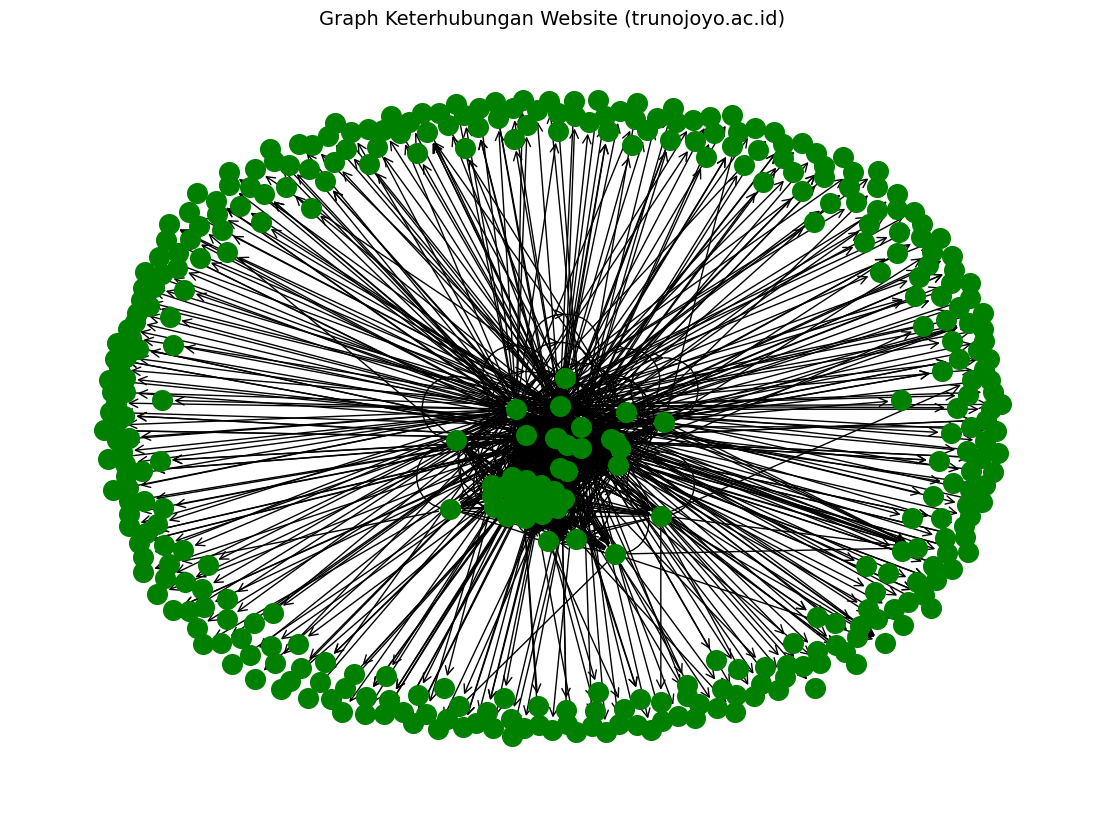

In [ ]:
# graph dari hasil crawling
graf = Graph_Crawling(tabel_hasil)

# Gambar graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(graf, k=0.3, seed=42)  # layout posisi node

nx.draw_networkx_nodes(graf, pos, node_size=200, node_color="green")
nx.draw_networkx_edges(graf, pos, arrowstyle="->", arrowsize=15, edge_color="black")
# kalau mau nampilkan link website, aktifkan :
# nx.draw_networkx_labels(graf, pos, font_size=8, font_family="sans-serif")

plt.title("Graph Keterhubungan Website (trunojoyo.ac.id)", fontsize=14)
plt.axis("off")
plt.show()